#### Imports

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from networkx.algorithms import bipartite
import random
import ast
import math

#### Load graph data

In [3]:
G = nx.Graph(name="Steam")


with open('../australian_users_items.json', encoding='utf-8') as f:
    for line in f:
        user = ast.literal_eval(line)

        user_id = user['steam_id']
        user_node = ('user', user_id)
        G.add_node(user_node, bipartite=0, node_type='user')

        for item in user['items']:
            playtime = item.get('playtime_forever', 0)

            if playtime == 0:
                continue  # Skip items with no playtime

            item_id = item['item_id']
            item_name = item['item_name']
            item_node = ('item', item_id)

            G.add_node(item_node, bipartite=1, node_type='item', name=item_name)

            # Use log scaling (prevents extreme values dominating)
            weight = math.log1p(playtime)

            G.add_edge(
                user_node,
                item_node,
                weight=weight,
                playtime=playtime 
            )

In [4]:
item_names = {
    n: data.get('name', 'unknown')
    for n, data in G.nodes(data=True)
    if data['node_type'] == 'item'
}

### Basic Graph Statistics

We compute the number of nodes, edges, density, and connected components to understand the overall structure of the network.

These metrics provide insight into:
- **Scale** of the dataset (number of users and items)
- **Sparsity** (interaction density is typically very low in recommendation systems)
- **Connectivity**, which determines how effectively information can propagate in graph-based models

A large, sparse graph with a dominant connected component is typical for real-world recommendation systems.

In [26]:
def basic_stats(G):
    n = G.number_of_nodes()
    m = G.number_of_edges()

    users = [n for n, d in G.nodes(data=True) if d['node_type'] == 'user']
    items = [n for n, d in G.nodes(data=True) if d['node_type'] == 'item']

    print(f"Nodes: {n}")
    print(f"Edges: {m}")
    print(f"Users: {len(users)}")
    print(f"Items: {len(items)}")

    avg_degree = sum(dict(G.degree()).values()) / n
    print(f"Average degree: {avg_degree:.2f}")

    density = nx.density(G)
    print(f"Density: {density:.6f}")

    components = list(nx.connected_components(G))
    print(f"Connected components: {len(components)}")

    largest_cc = max(components, key=len)
    print(f"Largest CC size: {len(largest_cc)}")


basic_stats(G)

Nodes: 97675
Edges: 3246352
Users: 87625
Items: 10050
Average degree: 66.47
Density: 0.000681
Connected components: 19223
Largest CC size: 78453


### Degree Distribution

We analyze the degree distribution separately for users and items.

This is important because:
- **Item degree** reflects popularity (how many users own a game)
- **User degree** reflects activity level (how many games a user owns)

In most real-world systems, degree distributions are **heavy-tailed**, meaning:
- A few items are extremely popular
- Most items have very few interactions

This has strong implications for recommendation bias and model design.

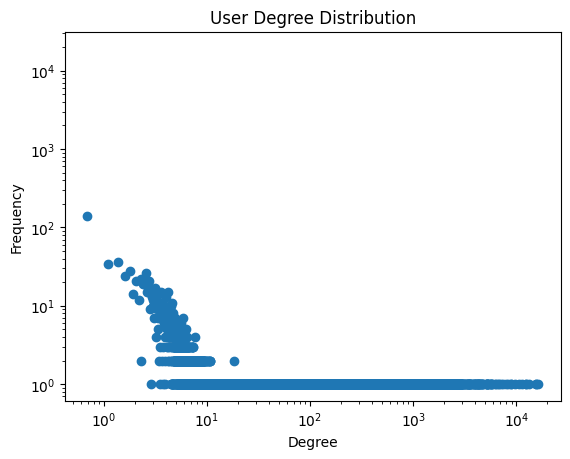

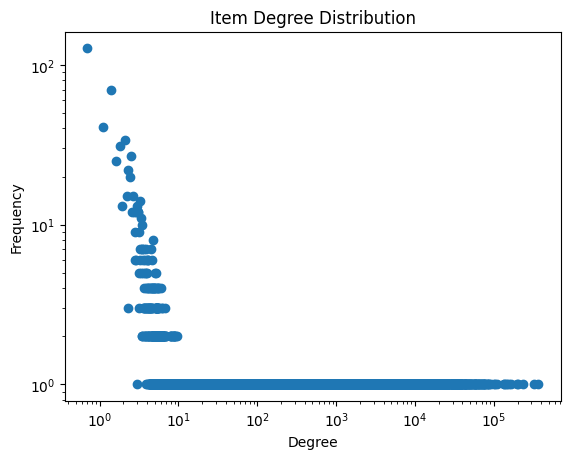

In [28]:
def degree_distribution(G):
    user_degrees = []
    item_degrees = []

    for node, deg in G.degree(weight='weight'):
        if G.nodes[node]['node_type'] == 'user':
            user_degrees.append(deg)
        else:
            item_degrees.append(deg)

    return user_degrees, item_degrees


def plot_degree_distribution(degrees, title):
    counts = Counter(degrees)
    x, y = zip(*sorted(counts.items()))

    plt.figure()
    plt.scatter(x, y)
    plt.xscale('log')
    plt.yscale('log')
    plt.title(title)
    plt.xlabel("Degree")
    plt.ylabel("Frequency")
    plt.show()


user_degrees, item_degrees = degree_distribution(G)
plot_degree_distribution(user_degrees, "User Degree Distribution")
plot_degree_distribution(item_degrees, "Item Degree Distribution")

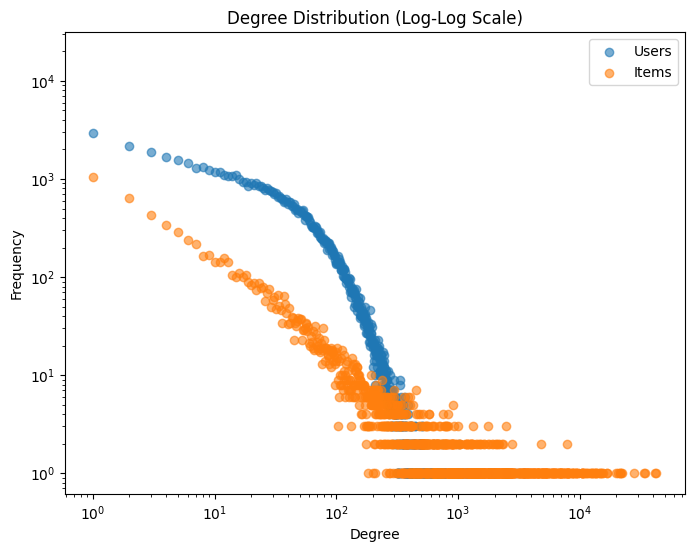

In [34]:
def plot_degree_distribution(G, save_path="artifacts/plots/degree_distribution.png"):
    user_degrees = []
    item_degrees = []

    for n in G.nodes():
        deg = G.degree(n)

        if G.nodes[n]['node_type'] == 'user':
            user_degrees.append(deg)
        else:
            item_degrees.append(deg)

    def prepare(degrees):
        counts = Counter(degrees)
        x, y = zip(*sorted(counts.items()))
        return x, y

    ux, uy = prepare(user_degrees)
    ix, iy = prepare(item_degrees)

    plt.figure(figsize=(8, 6))

    plt.scatter(ux, uy, label="Users", alpha=0.6)
    plt.scatter(ix, iy, label="Items", alpha=0.6)

    plt.xscale("log")
    plt.yscale("log")

    plt.xlabel("Degree")
    plt.ylabel("Frequency")
    plt.title("Degree Distribution (Log-Log Scale)")
    plt.legend()

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


plot_degree_distribution(G)

### Comparison with Random Graph Models

We compare the observed graph to:
- Erdős–Rényi random graph
- Configuration model

This helps determine whether the network structure is random or exhibits real-world properties.

Key insights:
- Real networks typically show **higher clustering** than random graphs
- Similarity to the configuration model indicates that the degree distribution explains much of the structure

This analysis helps validate whether the network follows a **scale-free or heavy-tailed structure**.

In [19]:
def sample_graph(G, size=10000):
    nodes = random.sample(list(G.nodes()), size)
    return G.subgraph(nodes).copy()


def compare_random_graphs(G):
    n = G.number_of_nodes()
    m = G.number_of_edges()

    # Erdős–Rényi
    p = (2 * m) / (n * (n - 1))
    G_er = nx.erdos_renyi_graph(n, p)

    # Configuration model
    degree_seq = [d for _, d in G.degree()]
    G_conf = nx.configuration_model(degree_seq)
    G_conf = nx.Graph(G_conf)
    G_conf.remove_edges_from(nx.selfloop_edges(G_conf))

    print("Original clustering:", nx.average_clustering(G))
    print("ER clustering:", nx.average_clustering(G_er))
    print("Config clustering:", nx.average_clustering(G_conf))


compare_random_graphs(sample_graph(G, size=10000))

Original clustering: 0.0
ER clustering: 0.0008102208902208902
Config clustering: 0.08667302219786781


### Centrality Analysis

We compute centrality measures such as:
- Degree centrality
- PageRank

These identify important nodes in the network:
- Highly central items are typically very popular
- Highly central users are highly active

Centrality can serve as a useful baseline signal in recommendation systems.

In [5]:
def centrality_analysis(G, sample_size=5000):
    sample_nodes = random.sample(list(G.nodes()), min(sample_size, G.number_of_nodes()))
    subG = G.subgraph(sample_nodes)

    deg_cent = nx.degree_centrality(subG)
    pagerank = nx.pagerank(subG)

    top_deg = sorted(deg_cent.items(), key=lambda x: x[1], reverse=True)[:10]
    top_pr = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:10]

    print("Top degree centrality:")
    for node, score in top_deg:
        print(item_names.get(node, node), score)

    print("\nTop PageRank:")
    for node, score in top_pr:
        print(item_names.get(node, node), score)


centrality_analysis(G)

Top degree centrality:
Sid Meier's Civilization V 0.14182836567313462
Insurgency 0.10002000400080016
BioShock Infinite 0.09001800360072014
Fistful of Frags 0.07881576315263053
SMITE 0.06721344268853771
Dead Island: Epidemic 0.0666133226645329
Call of Duty: Black Ops II 0.05781156231246249
Kerbal Space Program 0.054210842168433686
theHunter 0.052210442088417686
Call of Duty: Modern Warfare 2 0.05081016203240648

Top PageRank:
Sid Meier's Civilization V 0.042665523835157204
Insurgency 0.024281268968825202
BioShock Infinite 0.02229574138972331
Fistful of Frags 0.018193115847022056
SMITE 0.01611193625802806
Kerbal Space Program 0.01353117479910327
Dead Island: Epidemic 0.012959294909558612
Call of Duty: Black Ops II 0.012732512723979815
Call of Duty: Modern Warfare 2 0.012538852606096029
Middle-earth: Shadow of Mordor 0.011402164149114727


### Projection Graphs

We construct projected graphs:
- User–User (shared items)
- Item–Item (shared users)

These projections reveal implicit relationships:
- Users with similar preferences
- Items that are frequently co-purchased

The item–item projection is especially important for recommendation, as it captures similarity between products.

In [ ]:
from tqdm import tqdm
import os
import pickle

def weighted_item_projection(G):
    proj = nx.Graph()

    for u, data in tqdm(G.nodes(data=True)):
        if data['node_type'] != 'user':
            continue

        neighbors = sorted(
            G[u],
            key=lambda x: G[u][x].get('weight', 0),
            reverse=True
        )[:50]

        for i in range(len(neighbors)):
            for j in range(i + 1, len(neighbors)):
                item1 = neighbors[i]
                item2 = neighbors[j]

                w1 = G[u][item1].get('weight', 1)
                w2 = G[u][item2].get('weight', 1)

                # overlap-based similarity
                weight = min(w1, w2)

                if proj.has_edge(item1, item2):
                    proj[item1][item2]['weight'] += weight
                else:
                    proj.add_edge(item1, item2, weight=weight)

    return proj


def projection_analysis(G):
    item_proj = weighted_item_projection(G)

    import pickle
    with open("artifacts/item_proj.pkl", "wb") as f:
        pickle.dump(item_proj, f)

    print("Item projection nodes:", item_proj.number_of_nodes())

    return item_proj

if os.path.exists("artifacts/item_proj.pkl"):
    with open("artifacts/item_proj.pkl", "rb") as f:
        item_proj = pickle.load(f)
else:
    item_proj = projection_analysis(G)

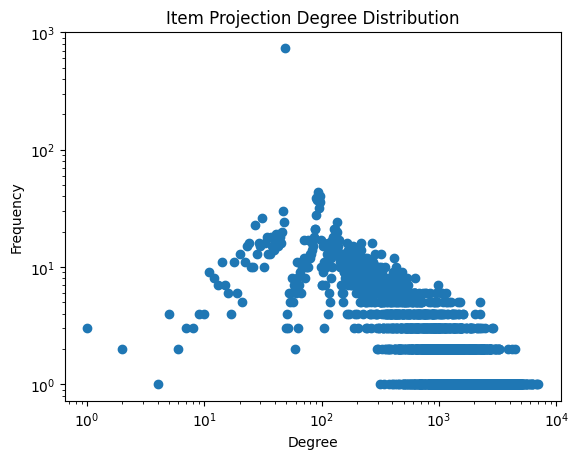

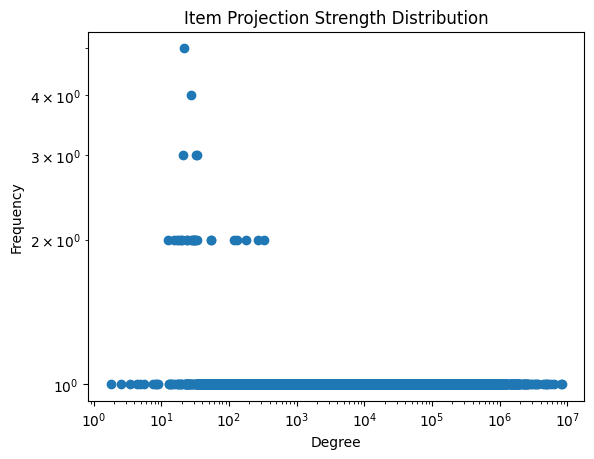

In [9]:
degrees = [d for _, d in item_proj.degree()]
plot_degree_distribution(degrees, "Item Projection Degree Distribution")

strength = dict(item_proj.degree(weight='weight'))
plot_degree_distribution(list(strength.values()), "Item Projection Strength Distribution")

In [11]:
pr = nx.pagerank(item_proj, weight='weight')

top_pr = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop PageRank:")
for node, score in top_pr:
    print(item_names.get(node, node), score)



Top PageRank:
Counter-Strike: Global Offensive 0.01594771281900503
Garry's Mod 0.015446902645471609
Left 4 Dead 2 0.012306892320355178
Terraria 0.011164110618556282
The Elder Scrolls V: Skyrim 0.009787769371376862
Unturned 0.009541049482883354
PAYDAY 2 0.009296391090535986
Borderlands 2 0.00889574045040187
Portal 2 0.008623092183466415
Warframe 0.00708724326671819


In [17]:
item = ('item', '519140')

neighbors = sorted(
    item_proj[item].items(),
    key=lambda x: x[1]['weight'],
    reverse=True
)[:10]

for node, score in neighbors:
    print(item_names.get(node, node), score)

Garry's Mod {'weight': 71.63202946101974}
Unturned {'weight': 69.34564634260198}
Counter-Strike: Global Offensive {'weight': 60.51416649709949}
Terraria {'weight': 41.28525560961773}
Heroes & Generals {'weight': 40.8410546206389}
Warframe {'weight': 35.45830412205812}
Left 4 Dead 2 {'weight': 34.40626864080065}
Counter-Strike: Source {'weight': 32.00252277121441}
Portal 2 {'weight': 31.83554344452235}
Dirty Bomb {'weight': 30.054902063878274}


### Community Detection

We apply community detection on the item–item projection graph.

This helps identify clusters of related items, which may correspond to:
- Game genres
- Player preference groups

Community structure is useful for:
- Understanding the dataset
- Improving recommendations through grouping and similarity

In [41]:
import networkx.algorithms.community as nx_comm


def filter_graph(G, min_weight=10):
    H = nx.Graph()

    for u, v, d in G.edges(data=True):
        if d.get("weight", 1) >= min_weight:
            H.add_edge(u, v, weight=d["weight"])

    return H


def community_detection(G_proj):
    communities = nx_comm.louvain_communities(G_proj, seed=42)

    print(f"Detected {len(communities)} communities")

    sizes = [len(c) for c in communities]
    print("Largest communities:", sorted(sizes, reverse=True)[:10])

    return communities

item_communities = community_detection(item_proj)

Detected 5 communities
Largest communities: [3311, 1715, 1574, 1023, 84]


In [42]:
node_community = {}

for i, comm in enumerate(item_communities):
    for node in comm:
        node_community[node] = i

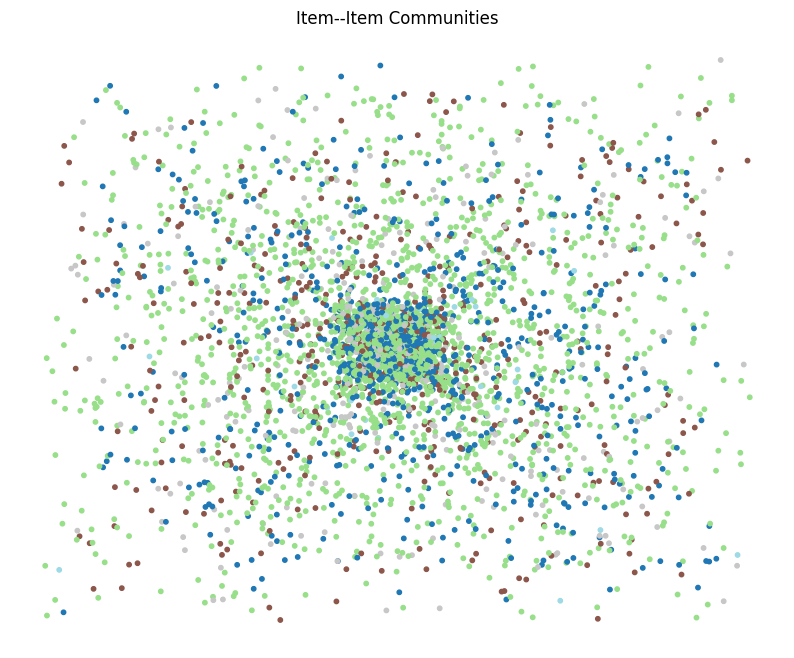

In [45]:
def plot_item_communities(G, node_community, save_path="artifacts/plots/item_communities.png"):
    plt.figure(figsize=(10, 8))

    pos = nx.spring_layout(G, seed=42)

    colors = [node_community.get(n, -1) for n in G.nodes()]

    nx.draw_networkx_nodes(
        G, pos,
        node_color=colors,
        node_size=10,
        cmap=plt.cm.tab20
    )

    # nx.draw_networkx_edges(G, pos, alpha=0.05)

    plt.title("Item--Item Communities")
    plt.axis("off")

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

# top_nodes = sorted(
#     item_proj.degree(weight="weight"),
#     key=lambda x: x[1],
#     reverse=True
# )[:1000]

plot_item_communities(filter_graph(item_proj), node_community)

### Assortativity

We measure degree assortativity to understand whether nodes tend to connect to others with similar degree.

In this context:
- Do highly active users interact with popular items?
- Or is interaction more evenly distributed?

This helps characterize the structure of user behavior and item popularity.

In [27]:
def assortativity(G):
    assort = nx.degree_assortativity_coefficient(G)
    print(f"Degree assortativity: {assort:.4f}")


assortativity(G)

Degree assortativity: -0.2179


### Path Analysis

We analyze shortest paths within the largest connected component.

This provides insight into:
- How closely connected the network is
- How efficiently information can propagate

Short average path lengths are typical in real-world networks and beneficial for graph-based learning methods.

In [25]:
import random

def approx_avg_shortest_path(G, sample_size=300):
    largest_cc = max(nx.connected_components(G), key=len)
    subG = G.subgraph(largest_cc).copy()

    nodes = list(subG.nodes())
    sample = random.sample(nodes, min(sample_size, len(nodes)))

    path_lengths = []

    for n in sample:
        lengths = nx.single_source_shortest_path_length(subG, n)
        path_lengths.extend(lengths.values())

    avg_length = sum(path_lengths) / len(path_lengths)

    print("Approx Avg shortest path:", avg_length)
    return avg_length


avg = approx_avg_shortest_path(sample_graph(G, size=10000))

Approx Avg shortest path: 3.4681940425531916


### Summary

The network exhibits key properties of real-world recommendation systems:
- High sparsity
- Heavy-tailed degree distributions
- Presence of highly popular items (hubs)

These characteristics will directly influence the design of the recommendation model, particularly Graph Neural Networks, which rely on graph structure for learning embeddings.

Next steps include implementing baseline models and training GNN-based recommenders.